In [1]:
import pandas as pd
from pathlib import Path
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import statistics as stat
import shutil

## Divide networks in tiles with the same number of cells per tile

In [2]:
def nb_chunks_same_cells1(n_cutting):
    """
    This function calculates the number of tiles in wich each sample should be divided 
    by calculating the proportion of cells to the smallest sample
    """
    nb_cells_p= {}
    n_cutting_p={}
    patients= []
    cells_per_chunk= {} 
    for file in files:
        patient = file.stem.split("-")[1]
        patients.append(patient)
        df= pd.read_parquet(file)
        nb_cells_p[patient]= len(df)
    nb_cells_min= min(nb_cells_p.values())
    
    for patient in patients:
        proportion= round(nb_cells_p[patient]/nb_cells_min, 3) #proportion of number of cells compared to min value
        n_cutting_p[patient]= int(round(np.sqrt(n_cutting * proportion))**2)
        cells_per_chunk[patient]= nb_cells_p[patient]/ n_cutting_p[patient]
    
    nb_cells_mean= round(np.mean(list(cells_per_chunk.values())),-2)
    return n_cutting_p, patients, nb_cells_mean




In [3]:
def nb_chunks_same_cells(n_cutting):
    """
    This function calculates the number of tiles in wich each sample should be divided 
    by calculating the proportion of cells to the middle sample
    """
    nb_cells_p= {}
    n_cutting_p={}
    patients= []
    cells_per_chunk= {} 
    for file in files:
        patient = file.stem.split("-")[1]
        patients.append(patient)
        df= pd.read_parquet(file)
        nb_cells_p[patient]= len(df)
    nb_cells_middle = np.mean(np.array(list(nb_cells_p.values())))
    
    for patient in patients:
        proportion= round(nb_cells_p[patient]/nb_cells_middle, 3) #proportion of number of cells compared to min value
        min_chunks = 4

        n_cut = int(round(np.sqrt(n_cutting * proportion))**2)
        n_cutting_p[patient] = max(min_chunks, n_cut)
        
        cells_per_chunk[patient]= nb_cells_p[patient]/ n_cutting_p[patient]
       
    nb_cells_mean = round(np.mean(list(cells_per_chunk.values())), -2)
    return n_cutting_p, patients, nb_cells_mean




In [4]:
def compute_bounds(df, n_parts, X, Y, patient):
    """
    This function splits a DataFrame into quantiles of order k maintaining the same number of cells per chunk. 

    """

    k = int(math.sqrt(n_parts))
    if k * k != n_parts:
        raise ValueError("n_parts has to be a perfect square, for example 4, 9 or 16.")

    if X not in df.columns or Y not in df.columns:
        raise ValueError(f"The DataFrame has to contain columns '{X}' and '{Y}'.")


    #Compute quantile boundries along the x axis (each region has the same number of cells)
    x_bounds = np.quantile(df[X], np.linspace(0, 1, k+1)) 

    #For each x quantile bin compute quantile boundries along the y axis
    y_bounds = []
    for i in range(k): 
        mask=(
        (df[X] >= x_bounds[i]) & 
        (df[X] <= x_bounds[i+1])
        )
        y_region = df.loc[mask, Y] 

        y_bounds.append(
            np.quantile(y_region, np.linspace(0, 1, k+1)) 
        ) 
    return k, x_bounds, y_bounds


In [5]:
def split_dataframe_to_parquet(df, X, Y, patient, k, x_bounds, y_bounds, save_files, output_dir):
    """This function generates parquet files of the splitted dataframes
    It also returns a dictionary containing for each chunk its identifier and the number of cells asociated"""
    df_temp = df.copy()

    # Divide cells along the x axes
    df_temp["cell_x"] = np.searchsorted(x_bounds, df_temp[X], side="right") - 1 
    df_temp["cell_x"] = df_temp["cell_x"].clip(0, k - 1)  
    
    #Divide the cells along the y axes
    df_temp["cell_y"] =  -1 
    for i in range(k): 
        mask= df_temp["cell_x"] ==i
        df_temp.loc[mask, "cell_y"] =(
            np.searchsorted(y_bounds[i], df_temp.loc[mask, Y], side= "right") -1
        )
    df_temp["cell_y"] = df_temp["cell_y"].clip(0, k - 1)


    #Create dictionnary containing for each chunk it's identity and the number of cells
    #Generate parquet files for each file
    chunk_id = 1
    df_length = {"index": [], "nb_cells": []}

    for j in range(k):
        for i in range(k):
            mask = (df_temp["cell_x"] == i) & (df_temp["cell_y"] == j)
            chunk_df = df_temp.loc[mask, df.columns].copy()
            df_length["index"].append(f"{patient}_{chunk_id}")
            df_length["nb_cells"].append(len(chunk_df))
            
            if save_files:
                
                output_path = output_dir / f"nodes_patient-{patient}-{chunk_id}.parquet"
                chunk_df.to_parquet(output_path, index=False)
                print(f"{output_path} sauvegardé avec {len(chunk_df)} lignes.")
            chunk_id += 1
    return df_length

In [6]:

def plot_divisions(df, X, Y, x_bounds, y_bounds,k, patient, save_files, output_dir):
    """This function plots a network with the lines of segmentation"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(df[X], df[Y], s=1, alpha=0.5)

    # vertical lines
    for xb in x_bounds[1:-1]:
        ax.axvline(xb, color="black", linewidth = 2)

    # horizontal lines per x-bin
    for i in range(k):
        for yb in y_bounds[i][1:-1]:

            ax.plot(
                [x_bounds[i], x_bounds[i+1]],
                [yb, yb],
                color="black",
                alpha= 1,
                linewidth= 2
            )

    ax.set_aspect("equal")
    ax.text(100,100,k**2)

 
    if save_files:
        output_dir_hist= output_dir / "histogram"
        output_dir_hist.mkdir(parents = True, exist_ok = True)
        plt.savefig(output_dir_hist/ f"plot_network{patient}.png", dpi=300, bbox_inches="tight")     
    plt.show()

In [7]:
def histogram_cells_per_chunk(df_length, n_cutting, save_files, show_histograms_per_patient, output_dir):
    """
    This function takes a DataFrame containing une column "nb_cells"
    and generates an histogram showing for each patient the number of cells per chunk.
    It also creates a general histogram with the number of cells per chunk per patient

    """
    nb_cells= df_length["nb_cells"]
    nb_cells_max = max(nb_cells)
    nb_cells_min = min(nb_cells)   
    mean_nb_cells= np.mean(nb_cells).round(0)

    df_length["patient"] = df_length["index"].str.split("_").str[0]
    df_length["chunk"] = df_length["index"].str.split("_").str[1]

    stats = df_length.groupby("patient")["nb_cells"].agg(["mean", "std"])
    plt.figure(figsize=(10,5))

    plt.bar(
        stats.index,
        stats["mean"],
        yerr=stats["std"],
        capsize=5,
        color="tab:blue",
        alpha=0.7
    )

    for patient in stats.index:
        y = df_length.loc[df_length["patient"] == patient, "nb_cells"]
       
        plt.scatter(
            [patient] * len(y),  # same x position
            y,
            color="black",
            zorder=3
        )
    plt.xlabel("Patient")
    plt.ylabel("Number of cells")
    plt.title(f"Number of cells per chunk ({n_cutting} chunks on average)")
    bars = plt.bar(
        stats.index,
        stats["mean"],
        yerr=stats["std"],
        capsize=5,
        color="tab:blue",
        alpha=0.7
    )

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + nb_cells_max/ 100,
            f"{bar.get_height():.0f}",
            ha="center",
            va="bottom"
        )
    plt.text(6.5, nb_cells_max ,
    f" Mean nb of cells: {mean_nb_cells}\nNb of cells max: {nb_cells_max}\nNb of cells min: {nb_cells_min}",
    ha= "right",
    va= "bottom",
    bbox= dict(facecolor= "white",
    edgecolor= "black",
    boxstyle= "round,pad=0.4"))

    if save_files:
        output_dir_hist= output_dir / "histogram"
        output_dir_hist.mkdir(parents = True, exist_ok = True)
        plt.savefig(output_dir_hist/ "cells_per_chunk.png", dpi=300, bbox_inches="tight")
        
    plt.show()

    if show_histograms_per_patient:
        n_patients= len(patients)
        ncols = 3
        nrows = int(np.ceil(n_patients / ncols))
        fig, axes = plt.subplots(
            ncols,
            nrows,
            figsize=(10, 3*nrows), 
            sharex= True,
            sharey= True)
        
        axes = axes.flatten()
        plt.suptitle(f"Number of cells in each chunk ({n_cutting} chunks)")
        for ax,patient in zip(axes, patients):
            df_length_patient = df_length.loc[df_length["patient"]== patient, ["nb_cells", "chunk"]] 

            nb_chunk = df_length_patient["chunk"]
            nb_cells = df_length_patient["nb_cells"]
            nb_cells_max = max(nb_cells)
            nb_cells_min = min (nb_cells)
            
            
            ax.bar(nb_chunk ,nb_cells, edgecolor="black")
            ax.set_title(f"Patient {patient}")
            ax.set_xlabel("Chunk")
            ax.set_ylabel("Number of cells")
            std_cells = df_length["nb_cells"].std().round(1)
            ax.text(
                0.98, 0.95,
                f"Cells max: {nb_cells_max}\nCells min: {nb_cells_min}",
                transform= ax.transAxes,
                ha="right",
                va="top",
                bbox=dict(boxstyle="round", facecolor= "white",alpha=0.8)
            )
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
        
            
        plt.show()


In [8]:
def copy_paste_files(output_dir):
    n_cutting_p, patients, nb_cells_mean= nb_chunks_same_cells(n_cutting)
    #Indicate folder to add files to
    files= sorted(output_dir.glob("nodes_*.parquet"))
    tysserand_dir= output_dir/ "Tysserand_Network"
    temp_dir= output_dir/ "temp/net_dir_mosna"
    tysserand_dir.mkdir(parents = True, exist_ok = True)
    temp_dir.mkdir(parents = True, exist_ok = True)
    assort_dir= output_dir/ "Assortativity"
    assort_dir.mkdir(parents = True, exist_ok = True)

    #-----------------------------------------------------------------------------------------------
    #Save files from folder "Tysserand"
    for file in files:
        patient= file.stem.split("-")[1].split("_")[0]
        nb_chunks= n_cutting_p[patient]
        if nb_chunks==1:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/Tysserand_Network")
        else:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/mes_chunks/mes_chunks{nb_chunks}/Tysserand_Network")
        files_source= sorted(source_path.glob(f"net_{patient}*.png"))
        for file1 in files_source:
            shutil.copyfile(
                file1,
                tysserand_dir / file1.name
            )
    #-----------------------------------------------------------------------------------------------
    #Save files from folder "temp/net_dir_mosna"
    for file in files:
        patient= file.stem.split("-")[1].split("_")[0]
        nb_chunks= n_cutting_p[patient]
        if nb_chunks==1:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/temp/net_dir_mosna")
        else:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/mes_chunks/mes_chunks{nb_chunks}/temp/net_dir_mosna")
        files_source= sorted(source_path.glob(f"*_patient-{patient}*.parquet"))
        for file1 in files_source:
            shutil.copyfile(
                file1,
                temp_dir / file1.name
            )
    #-----------------------------------------------------------------------------------------------
    #Assortativity net_stat
    all_rows=[]
    for patient in patients:
        nb_chunks= n_cutting_p[patient]
        if nb_chunks== 1:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/Assortativity")
        else:
            source_path= Path(f"/home/a.diaz-garcia-guij/Documents/Xenium analysis/nodes/mes_chunks/mes_chunks{nb_chunks}/Assortativity")
        df= pd.read_csv(source_path/"net_stat.csv")
        patient_rows= df[df["id"].str.startswith(f"patient-{patient}")]
        all_rows.append(patient_rows)
    net_stat_final= pd.concat(all_rows, ignore_index=True)
    net_stat_final.to_csv(output_dir / "Assortativity" / "net_stat.csv", index=False)




In [9]:
def split_network_into_tiles(save_dir,n_cutting, files, save_files, show_histograms_per_patient, show_divisions, copy_files):
    """
    This function partitions spatial networks into a fixed number of tiles containing the same number of cells
    dividing the dataframe by quantiles

    It uses the following functions: 
        -compute_bounds() computes bounds in the X and Y axis
        -plot_divisions() vidualizes the divisions on top of the cell coordinates
        -split_dataframe_to_parquet() exports parquet files
        -histogram_cells_per_chunk() shows distribution of cells per tile


    Parameters
    ----------
    n_cutting: int
        Number of tiles, it has to be a perfect square (ex: 4, 9, 16)
    
    change options to save parquet files, show all histograms for each patient and segmented networks with
    save_files= True
    show_histograms_per_patient= True
    show_divisions= True)
    
        """
    n_cutting_p, patients, nb_cells_mean = nb_chunks_same_cells(n_cutting)


    all_lengths = []
    
    for file in files: 
        patient= file.stem.split("-")[1]
        patients.append(patient)
        df = pd.read_parquet(file)
        output_dir=Path(f"{save_dir}/chunks/{n_cutting}chunks_adjusted")
        if save_files:
            output_dir.mkdir(parents = True, exist_ok = True)

        k, x_bounds, y_bounds = compute_bounds(df, n_cutting_p[patient], "x_centroid", "y_centroid", patient)
        if show_divisions:
            plot_divisions(df, "x_centroid", "y_centroid", x_bounds, y_bounds, k, patient, True, output_dir)

        df_length_dict = split_dataframe_to_parquet(
            df,
            "x_centroid",
            "y_centroid",
            patient,
            k,
            x_bounds,
            y_bounds,
            save_files, 
            output_dir)

        df_length_df = pd.DataFrame(df_length_dict)
        all_lengths.append(df_length_df)

        
    df_length = pd.concat(all_lengths, ignore_index=True)
    df_length.head()
        
    histogram_cells_per_chunk(df_length, n_cutting, save_files, show_histograms_per_patient, output_dir)
    if copy_files== True:
        copy_paste_files(output_dir)


    

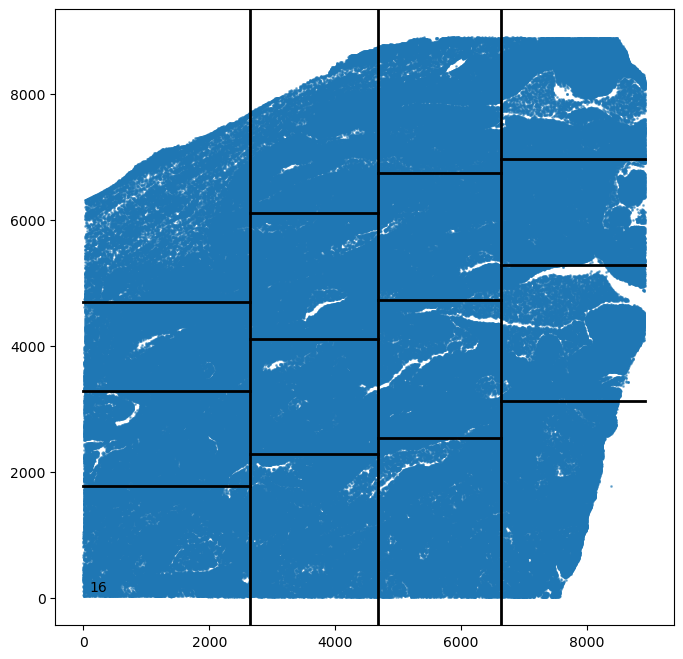

nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-1.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-2.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-3.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-4.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-5.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-6.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-7.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-8.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adjusted/nodes_patient-01_sample-9.parquet sauvegardé avec 43075 lignes.
nodes/chunks/5000/chunks/16chunks_adj

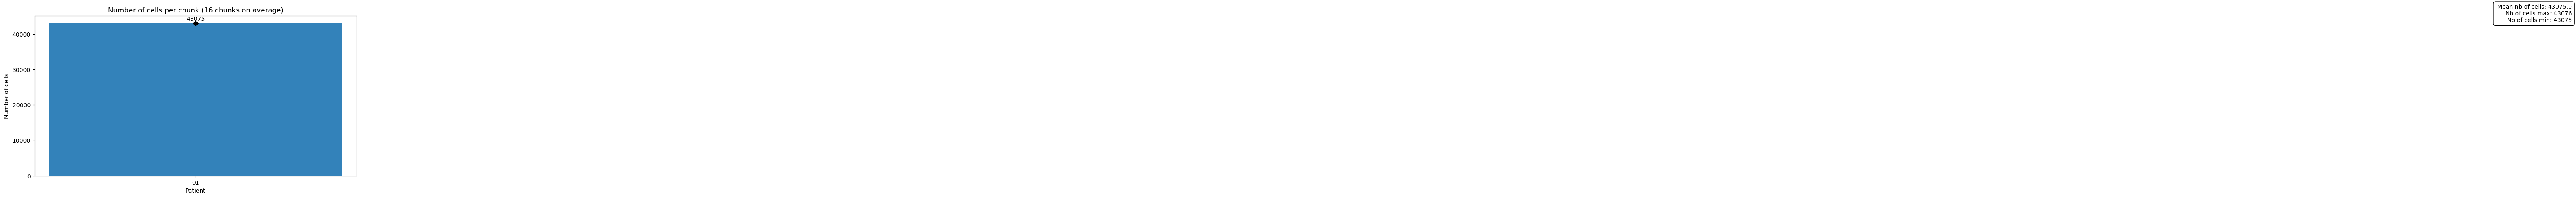

In [10]:
net_path = Path("./nodes/nodes_with_genes/5000")
files = sorted(net_path.glob("nodes_*.parquet"))
save_dir = Path("./nodes/chunks/5000")
save_dir.mkdir(parents = True, exist_ok = True)
n_cutting= 16
split_network_into_tiles(save_dir = save_dir,
                        n_cutting= n_cutting,
                        files= files, 
                        save_files= True, 
                        show_histograms_per_patient= False,
                        show_divisions= True, 
                        copy_files= False)